In [ ]:
# Lab 4b

In [2]:
import pandas as pd
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader
import torchvision.io as tv_io
import torchvision.transforms.v2 as transforms
import torchvision.transforms.functional as F
import matplotlib.pyplot as plt
from utils import MyConvBlock

import platform

print("Torch Loaded")

Torch Loaded


In [3]:
def get_platform_device():
    '''

    Detects the OS and the best GPU to use on the device

    '''
    
    os_name = platform.system()
    processor = platform.processor()
    

    if torch.cuda.is_available():
        device = torch.device("cuda")
        platform_info = f"Nvidia GPU via CUDA ({os_name})"
    elif torch.backends.mps.is_available():
        device = torch.device("mps")
        platform_info = f"Apple Silicon via MPS ({os_name})"
    else:
        device = torch.device("cpu")
        platform_info = f"CPU fallback ({os_name} {processor})"
    
    print(f"Platform detected: {platform_info}")
    return device

device = get_platform_device()
print(f"Using device: {device}")

Platform detected: Apple Silicon via MPS (Darwin)
Using device: mps


In [4]:
torch.serialization.add_safe_globals([torch.nn.modules.container.Sequential])
model = torch.load('model.pth', map_location=device, weights_only=False)
model

Sequential(
  (0): MyConvBlock(
    (model): Sequential(
      (0): Conv2d(1, 25, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(25, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Dropout(p=0, inplace=False)
      (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
  )
  (1): MyConvBlock(
    (model): Sequential(
      (0): Conv2d(25, 50, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(50, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Dropout(p=0.2, inplace=False)
      (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
  )
  (2): MyConvBlock(
    (model): Sequential(
      (0): Conv2d(50, 75, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(75, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Dropout(p=0, 

In [5]:
next(model.parameters()).device

device(type='mps', index=0)

In [6]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

def show_image(image_path):
    image = mpimg.imread(image_path)
    plt.imshow(image, cmap='gray')

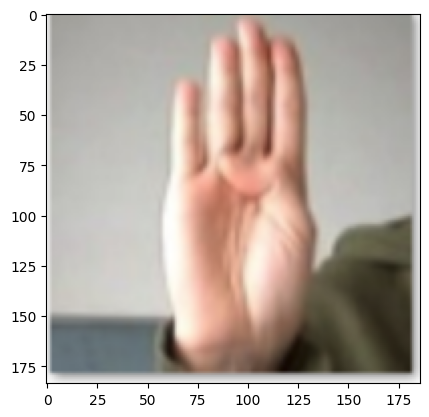

In [8]:
filepath = "data/asl_images/b.png"
show_image(filepath)

In [9]:
image = tv_io.read_image(filepath, tv_io.ImageReadMode.GRAY)
image

tensor([[[247, 223, 178,  ..., 223, 231, 238],
         [245, 221, 178,  ..., 213, 223, 232],
         [244, 220, 177,  ..., 204, 217, 228],
         ...,
         [247, 243, 238,  ..., 223, 231, 238],
         [249, 246, 243,  ..., 232, 238, 243],
         [250, 248, 246,  ..., 240, 243, 246]]], dtype=torch.uint8)

In [10]:
image.shape

torch.Size([1, 184, 186])

In [11]:
IMG_WIDTH = 28
IMG_HEIGHT = 28

preprocess_trans = transforms.Compose([
    transforms.ToDtype(torch.float32, scale=True), # Converts [0, 255] to [0, 1]
    transforms.Resize((IMG_WIDTH, IMG_HEIGHT)),
    transforms.Grayscale()  # From Color to Gray
])

In [12]:
processed_image = preprocess_trans(image)
processed_image


tensor([[[0.6960, 0.6279, 0.6348, 0.6493, 0.6584, 0.6599, 0.6638, 0.6630,
          0.6652, 0.6677, 0.6711, 0.6696, 0.6661, 0.6677, 0.7103, 0.6559,
          0.6369, 0.6507, 0.6464, 0.6379, 0.6293, 0.6216, 0.6139, 0.6074,
          0.5984, 0.5895, 0.5836, 0.6977],
         [0.7013, 0.6388, 0.6480, 0.6578, 0.6647, 0.6687, 0.6709, 0.6734,
          0.6746, 0.6794, 0.6814, 0.6784, 0.6902, 0.6801, 0.7648, 0.6606,
          0.5610, 0.6348, 0.6418, 0.6509, 0.6417, 0.6308, 0.6252, 0.6197,
          0.6095, 0.6007, 0.5923, 0.6773],
         [0.7061, 0.6479, 0.6588, 0.6668, 0.6743, 0.6811, 0.6845, 0.6848,
          0.6872, 0.6898, 0.6913, 0.6909, 0.7671, 0.6833, 0.6945, 0.6803,
          0.4720, 0.6061, 0.5686, 0.6548, 0.6566, 0.6471, 0.6380, 0.6273,
          0.6198, 0.6124, 0.6078, 0.6837],
         [0.7165, 0.6603, 0.6699, 0.6770, 0.6821, 0.6880, 0.6959, 0.7001,
          0.7027, 0.7014, 0.7009, 0.7041, 0.8257, 0.6885, 0.6387, 0.7202,
          0.4938, 0.6614, 0.5266, 0.6351, 0.6649, 0.6595,

In [13]:
processed_image.shape

torch.Size([1, 28, 28])

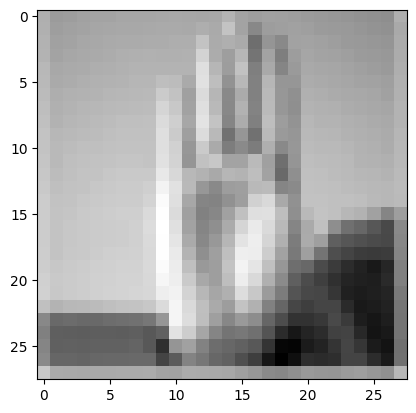

In [14]:
plot_image = F.to_pil_image(processed_image)
plt.imshow(plot_image, cmap='gray')

In [15]:
batched_image = processed_image.unsqueeze(0)
batched_image.shape

torch.Size([1, 1, 28, 28])

In [16]:
batched_image_gpu = batched_image.to(device)
batched_image_gpu.device

device(type='mps', index=0)

In [17]:
output = model(batched_image_gpu)
output

tensor([[-28.2260,  11.6234,  -1.4430, -22.7579, -12.9332,  -9.8475,  -9.7592,
         -25.2294, -15.1599, -13.9985,  -8.9183, -14.1733, -18.5842, -23.7573,
          -6.0945, -22.9131, -25.4889, -29.7992, -19.4828,  -5.6962, -20.7392,
          -1.5204, -15.9286, -23.3145]], device='mps:0',
       grad_fn=<LinearBackward0>)

In [18]:
prediction = output.argmax(dim=1).item()
prediction

1

In [19]:
alphabet = "abcdefghiklmnopqrstuvwxy"

In [22]:
alphabet[prediction]

'b'

In [25]:
def predict_letter(filepath: str) -> str:
    show_image(filepath) # Show image
    image = tv_io.read_image(filepath, tv_io.ImageReadMode.GRAY)
    image = preprocess_trans(image)
    image = image.unsqueeze(0)
    image = image.to(device)
    output = model(image)
    prediction = output.argmax(dim=1).item()
    predicted_letter = alphabet[prediction]
    return predicted_letter

'b'

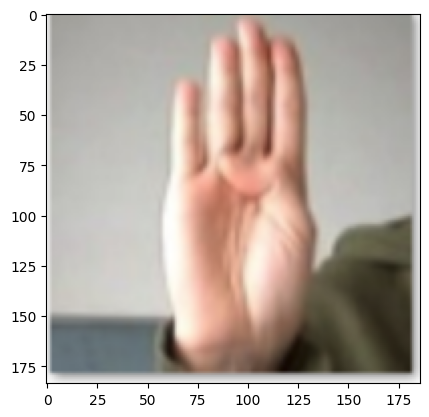

In [27]:
predict_letter(filepath=filepath)

'a'

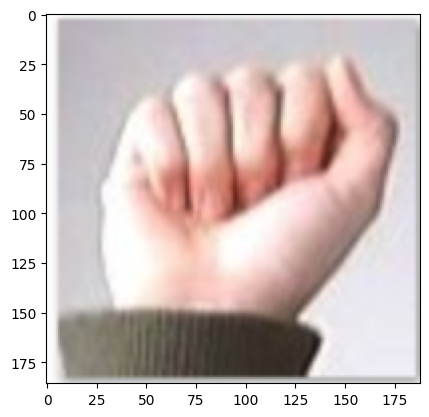

In [28]:
predict_letter(filepath="data/asl_images/a.png")

In [29]:
import IPython
app = IPython.Application.instance()
app.kernel.do_shutdown(True)

{'status': 'ok', 'restart': True}